In [1]:
using Pkg
Pkg.add("Random")
Pkg.add("JuMP")
Pkg.add("Gurobi")
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("Plots")

using JuMP, Gurobi, CSV, DataFrames

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Measures ──────────────── v0.3.3
   Installed PDMats ────────────────── v0.11.31
   Installed PlotUtils ─────────────── v1.4.4
   Installed OffsetArrays ──────────── v1.14.1
   Installed StatsFuns ─────────────── v1.3.2
   Installed MutableArithmetics ────── v1.5.1
   Installed StaticArrays ──────────── v1.9.7
   Installed FFMPEG ────────────────── v0.4.5
   Installed JLD2 ──────────────────── v0.6.3
   Installed Distances ─────────────── v0.10.11
   Installed PtrArrays ─────────────── v1.2.1
   Installed NearestNeighbors ──────── v0.4.20
   Installed CodecBzip2 ────────────── v0.8.4
   Installed SpecialFunctions ──────── v2.4.0
   Installed BenchmarkTools ────────── v1.5.0
   Installed MathOptInterface ──────── v1.31.2
   Installed StaticArraysCore ──────── v1.4.3
   Installed ChainRulesCore ────────── v1.25.0
   Installed StableRNGs ────────────── v1.0.4
   Installed JuMP ───────

### First model: λ = 0 and α = 0

#### Objective: minimize ∑_{t,i,a} g_i * w_{i,t,a}
#### Dynamics:
####   w[i,t+1,a+1] = w[i,t,a] - x[i,t,a]
####   w[i,t,1]     = N[i,t]  (new arrivals at a=0)

#### Capacity per time t is fixed input Cap[t]

In [19]:
waiting_df = CSV.read("ED_treatment_time.csv", DataFrame)
arrivals_df = CSV.read("ED_arrivals_2.csv", DataFrame)

# Add severity_score column (0 = trivial, 1 = mild, 2 = moderate, 3 = severe, 4 = critical) 
# based on ESI/CTAS–style acuity, expected risk, potential for rapid deterioration, and clinical priority
waiting_df.severity_score = zeros(Int, nrow(waiting_df))

waiting_df.severity_score[1] = 1
waiting_df.severity_score[2] = 3
waiting_df.severity_score[3] = 3
waiting_df.severity_score[4] = 1
waiting_df.severity_score[5] = 1
waiting_df.severity_score[6] = 1
waiting_df.severity_score[7] = 2
waiting_df.severity_score[8] = 4
waiting_df.severity_score[9] = 2
waiting_df.severity_score[10] = 0
waiting_df.severity_score[11] = 1
waiting_df.severity_score[12] = 2
waiting_df.severity_score[13] = 4
waiting_df.severity_score[14] = 4
waiting_df.severity_score[15] = 1
waiting_df.severity_score[16] = 1
waiting_df.severity_score[17] = 1
waiting_df.severity_score[18] = 0
waiting_df.severity_score[19] = 1
waiting_df.severity_score[20] = 2

waiting_df

Row,group,code,name,typical_treatment_time,severity_score
,String7,Int64,String,Float64,Int64
1,Disease,1,"Symptoms, signs, and abnormal clinical and laboratory findings",4.5,1
2,Disease,2,Injury and poisoning,5.0,3
3,Disease,3,Diseases of the respiratory system,8.0,3
4,Disease,4,Diseases of the musculoskeletal system and connective tissue,3.0,1
5,Disease,5,Diseases of the digestive system,1.0,1
6,Disease,6,Diseases of the genitourinary system,3.0,1
7,Disease,7,"Mental, behavioral, and neurodevelopmental disorders",10.0,2
8,Disease,8,Diseases of the circulatory system,6.0,4
9,Disease,9,Certain infectious and parasitic diseases,4.0,2


In [3]:
I = 1:20
T = 24
A = 0:T

# Service time per disease τ_i  we will take from typical_wait_hours
tau = Dict(i => waiting_df.typical_treatment_time[i] for i in I)

# Cost per waiting patient g_i  kept at 1 for the first model
g = Dict(i => 1.0 for i in I)

# Fixed capacity per period (e.g., physician-hours per hour)
# Cap[t] = nb_physician * physician_efficacity
Cap = Dict(t => 1000 for t in 1:T)

# Build N as a Dict[(i,t)] from the file
N = Dict((Int(row.disease_index), Int(row.t)) => Int(row.arrivals) for row in eachrow(arrivals_df))

# N[(3, 12)] = arrivals for disease 3 at hour 12

Dict{Tuple{Int64, Int64}, Int64} with 480 entries:
  (11, 17) => 72
  (16, 14) => 72
  (18, 16) => 72
  (17, 12) => 60
  (8, 15)  => 42
  (16, 16) => 72
  (19, 14) => 72
  (7, 18)  => 30
  (7, 8)   => 30
  (14, 15) => 84
  (7, 24)  => 18
  (1, 9)   => 30
  (15, 23) => 36
  (19, 16) => 72
  (2, 17)  => 36
  (10, 17) => 36
  (18, 18) => 60
  (18, 8)  => 60
  (15, 12) => 60
  ⋮        => ⋮

In [4]:
model = Model(Gurobi.Optimizer)
# set_optimizer_attribute(model, "OutputFlag", 0)  # optional example

@variable(model, w[i in I, t in 1:T, a in 0:T] >= 0, Int)
@variable(model, x[i in I, t in 1:T, a in 0:T] >= 0, Int)

# x ≤ w
@constraint(model, [i in I, t in 1:T, a in 0:T], x[i,t,a] <= w[i,t,a])

# New arrivals at age 0
@constraint(model, [i in I, t in 1:T], w[i,t,0] == N[(i,t)])

# Optional, no initial backlog older than a = 0 at t = 1
@constraint(model, [i in I, a in 1:T], w[i,1,a] == 0)

# Queue dynamics, avoid out of bounds on t+1 and a+1
@constraint(model, [i in I, t in 1:T-1, a in 0:T-1],
    w[i, t+1, a+1] == w[i,t,a] - x[i,t,a]
)

# Capacity per period
@constraint(model, [t in 1:T],
    sum(tau[i] * x[i,t,a] for i in I, a in 0:T) <= Cap[t]
)

@objective(model, Min, sum(g[i] * w[i,t,a] for i in I, t in 1:T, a in 0:T))

optimize!(model)


Set parameter Username
Set parameter LicenseID to value 2697134
Academic license - for non-commercial use only - expires 2026-08-20
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Optimize a model with 24024 rows, 24000 columns and 70080 nonzeros
Model fingerprint: 0xbc4ab2d7
Variable types: 0 continuous, 24000 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+00, 1e+03]
Found heuristic solution: objective 136441.00000
Presolve removed 23561 rows and 18490 columns
Presolve time: 0.02s
Presolved: 463 rows, 5510 columns, 11010 nonzeros
Variable types: 0 continuous, 5510 integer (0 binary)
Found heuristic solution: objective 135915.00000

Root relaxation: objective 1.070084e+05, 898 iterations, 0.01 seconds (0.02 work units)

    Node

### Problem of this model (notes from Elie)

#### Here we make no use of age in queue "a" (no constraints on it just added-computational and complexity)
#### See next model where we take out age in queue "a" (interpretation: we dont care at all about the waiting time, we just consider severity)
#### Discussions: no need to optimize as we just allocate physicians to the most severity patient case.
#### Further models to take this into consideration and the need to have a complex model that requires real optimization.

In [5]:
println("Status: ", termination_status(model))
println("Objective: ", objective_value(model))

# Quick summaries
treated_per_t = Dict(t => value(sum(x[i,t,a] for i in I, a in 0:T)) for t in 1:T)
waiting_per_t = Dict(t => value(sum(w[i,t,a] for i in I, a in 0:T)) for t in 1:T)

# println("\nTotal treated per hour:")
# for t in 1:T
#     println("t=$(t): ", treated_per_t[t])
# end

println("\nTotal waiting per hour:")
for t in 1:T
    println("t=$(t): ", waiting_per_t[t])
end


Status: OPTIMAL
Objective: 107027.0

Total waiting per hour:
t=1: 360.0
t=2: 421.0
t=3: 661.0
t=4: 492.0
t=5: 422.0
t=6: 554.0
t=7: 793.0
t=8: 1344.0
t=9: 1831.0
t=10: 2678.0
t=11: 3132.0
t=12: 3619.0
t=13: 4646.0
t=14: 5264.0
t=15: 6095.0
t=16: 6730.0
t=17: 7380.0
t=18: 7851.0
t=19: 8158.0
t=20: 8480.0
t=21: 8803.0
t=22: 8946.0
t=23: 9104.0
t=24: 9263.0


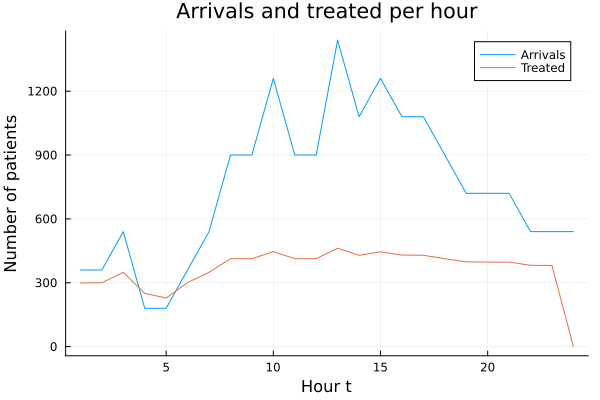

In [6]:
using Plots

# total arrivals per hour (data input)
arrivals_per_t = [sum(N[(i,t)] for i in I) for t in 1:T]

# total treated per hour (model output)
treated_per_t  = [sum(value(x[i,t,a]) for i in I, a in 0:T) for t in 1:T]

plot(1:T, arrivals_per_t,
     label = "Arrivals",
     xlabel = "Hour t",
     ylabel = "Number of patients",
     title = "Arrivals and treated per hour")

plot!(1:T, treated_per_t,
      label = "Treated")


Status: OPTIMAL
Objective: 107027.0


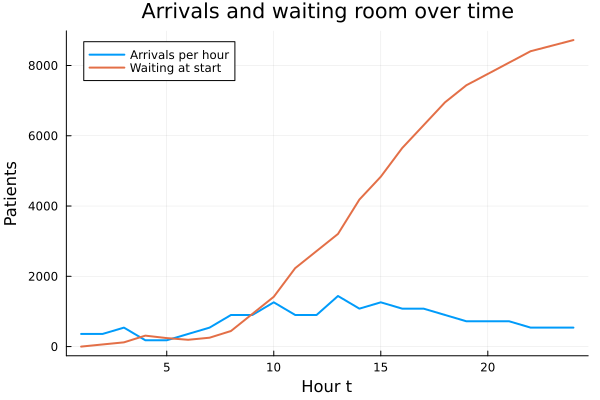

In [7]:
using Plots

# Arrivals per hour from the Dict N
arrivals_per_t = [sum(N[(i,t)] for i in I) for t in 1:T]

# Waiting room count at the start of each hour
waiting_per_t_vec = [value(sum(w[i,t,a] for i in I, a in 1:T)) for t in 1:T]

println("Status: ", termination_status(model))
println("Objective: ", objective_value(model))

# Line plot
plt = plot(1:T, arrivals_per_t,
    label = "Arrivals per hour",
    xlabel = "Hour t",
    ylabel = "Patients",
    title = "Arrivals and waiting room over time",
    legend = :topleft,
    lw = 2,
)
plot!(plt, 1:T, waiting_per_t_vec, label = "Waiting at start", lw = 2)


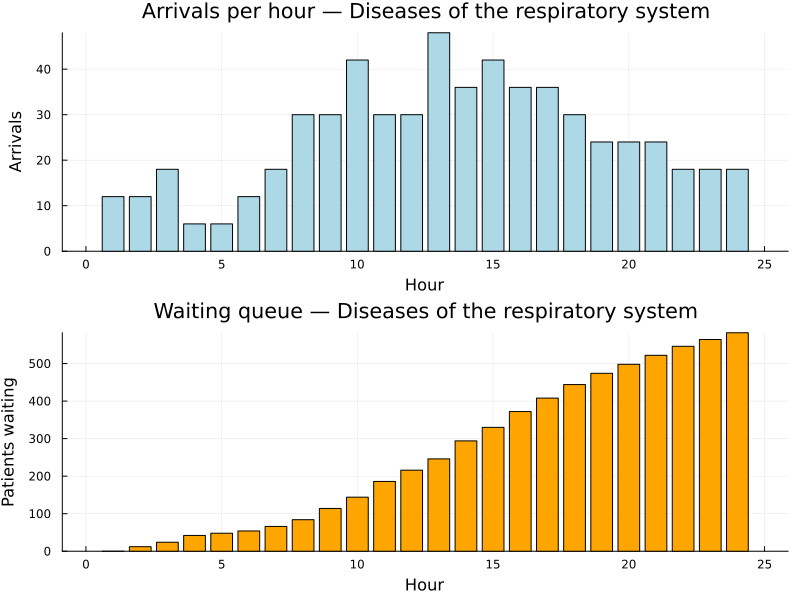

In [8]:
using Plots


function plot_disease_summary(disease_name::String)
    # Look up the disease index from the arrivals DataFrame
    rows = filter(:disease_name => ==(disease_name), arrivals_df)
    if nrow(rows) == 0
        println("Disease not found: ", disease_name)
        return
    end
    i = unique(rows.disease_index)[1]

    # Compute arrivals per hour for this disease
    arrivals_i = [N[(i,t)] for t in 1:T]

    # Compute queue (sum over all ages) from model results
    queue_i = [value(sum(w[i,t,a] for a in 1:T)) for t in 1:T]

    # Plot side by side "boxes" (bar charts)
    plt1 = bar(1:T, arrivals_i,
        xlabel = "Hour",
        ylabel = "Arrivals",
        title = "Arrivals per hour — $(disease_name)",
        legend = false,
        color = :lightblue,
    )

    plt2 = bar(1:T, queue_i,
        xlabel = "Hour",
        ylabel = "Patients waiting",
        title = "Waiting queue — $(disease_name)",
        legend = false,
        color = :orange,
    )

    # Combine vertically
    plot(plt1, plt2, layout = (2,1), size = (800,600))
end

plot_disease_summary("Diseases of the respiratory system")

# Diseases of the respiratory system


### Some modifications from the first code

In [20]:
I = 1:20
T = 24

# Service time per disease τ_i  (as before)
tau = Dict(i => waiting_df.typical_treatment_time[i] for i in I)

# --- SEVERITY WEIGHTS -------------------------------------------------
# Example: severity_score already in your data (replace with whatever you have)
severity = Dict(i => waiting_df.severity_score[i] for i in I)

# Cost per waiting patient per hour: higher for more severe diseases
g = Dict(i => severity[i] for i in I)

# Fixed capacity per period (e.g., physician-hours per hour)
Cap = Dict(t => 1000.0 for t in 1:T)

# Arrivals: N[(i,t)] = arrivals of disease i at hour t (as before)
N = Dict((Int(row.disease_index), Int(row.t)) => Float64(row.arrivals)
         for row in eachrow(arrivals_df))

# Optional: initial backlog at t = 1 (if you have it; otherwise keep 0)
initial_backlog = Dict(i => 0.0 for i in I)

# ----------------------------------------------------------------------
# MODEL: W[i,t] = number waiting at start of period t
#        X[i,t] = number treated during period t
# ----------------------------------------------------------------------

model = Model(Gurobi.Optimizer)

# Relaxed (continuous) variables
@variable(model, W[i in I, t in 1:T] >= 0)
@variable(model, X[i in I, t in 1:T] >= 0)

# Queue balance
# Convention: N[(i,t)] arrive at the start of period t and can be treated in t.
@constraint(model, [i in I],
    W[i,1] == initial_backlog[i] + N[(i,1)]
)

@constraint(model, [i in I, t in 2:T],
    W[i,t] == W[i,t-1] - X[i,t-1] + N[(i,t)]
)

# You can’t treat more than you have waiting
@constraint(model, [i in I, t in 1:T],
    X[i,t] <= W[i,t]
)

# Capacity per period
@constraint(model, [t in 1:T],
    sum(tau[i] * X[i,t] for i in I) <= Cap[t]
)

# ----------------------------------------------------------------------
# TERMINAL BACKLOG PENALTY
# ----------------------------------------------------------------------
# Penalize remaining queue at the end to avoid pushing everything to t = T.
# You can tune this; here we multiply g[i] by a factor.
terminal_factor = 5.0
h = Dict(i => terminal_factor * g[i] for i in I)

@objective(model, Min,
    # Total weighted waiting over the horizon
    sum(g[i] * W[i,t] for i in I, t in 1:T)
    +
    # Penalty on remaining backlog at final period
    sum(h[i] * W[i,T] for i in I)
)

optimize!(model)

Set parameter Username
Set parameter LicenseID to value 2697134
Academic license - for non-commercial use only - expires 2026-08-20
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Optimize a model with 984 rows, 960 columns and 2840 nonzeros
Model fingerprint: 0x1043f114
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+00, 1e+03]
Presolve removed 565 rows and 510 columns
Presolve time: 0.00s
Presolved: 419 rows, 450 columns, 2808 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.9016000e+04   3.988499e+03   0.000000e+00      0s
     336    2.3299387e+05   0.000000e+00   0.000000e+00      0s

Solved in 336 iterations and 0.01 seconds (0.01 work units)
Optimal objective  2.329938667e+05

User-callback calls 443, t

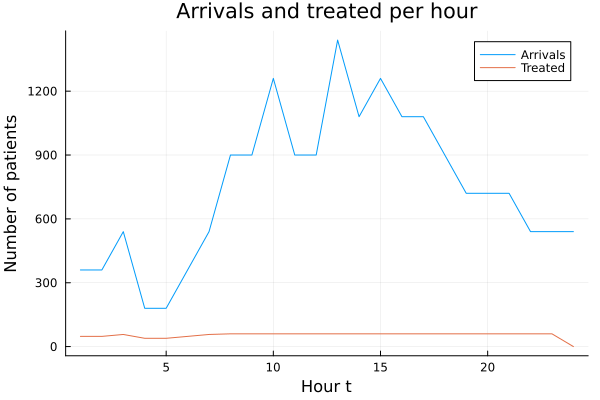

In [21]:
# total arrivals per hour (data input)
arrivals_per_t = [sum(N[(i,t)] for i in I) for t in 1:T]

# total treated per hour (model output)
treated_per_t  = [sum(value(x[i,t,a]) for i in I, a in 0:T) for t in 1:T]

plot(1:T, arrivals_per_t,
     label = "Arrivals",
     xlabel = "Hour t",
     ylabel = "Number of patients",
     title = "Arrivals and treated per hour")

plot!(1:T, treated_per_t,
      label = "Treated")

Status: OPTIMAL
Objective: 232993.86666666667


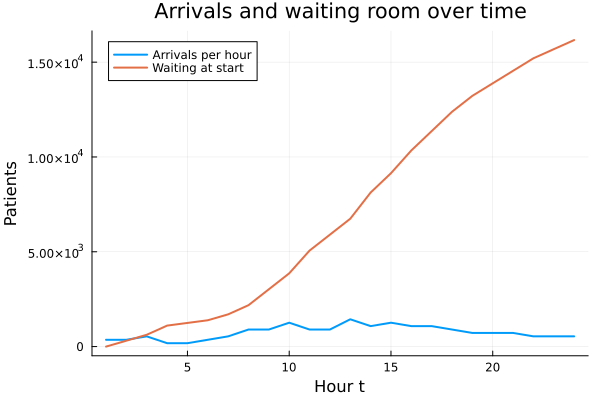

In [22]:
# Arrivals per hour from the Dict N
arrivals_per_t = [sum(N[(i,t)] for i in I) for t in 1:T]

# Waiting room count at the start of each hour
waiting_per_t_vec = [value(sum(w[i,t,a] for i in I, a in 1:T)) for t in 1:T]

println("Status: ", termination_status(model))
println("Objective: ", objective_value(model))

# Line plot
plt = plot(1:T, arrivals_per_t,
    label = "Arrivals per hour",
    xlabel = "Hour t",
    ylabel = "Patients",
    title = "Arrivals and waiting room over time",
    legend = :topleft,
    lw = 2,
)
plot!(plt, 1:T, waiting_per_t_vec, label = "Waiting at start", lw = 2)


#### Many problems with this model: we just allocate physician to the most in need without taking into consideration the waiting time.
#### As a matter of fact, we don't need an optimized model to do this.

What follows take into consideration the waiting time. We will se 2 ways to take it into consideration.

In [43]:
# ----------------------------------------------------------------------
# Sets
# ----------------------------------------------------------------------
I = 1:20          # disease/symptom indices (as in your table)
T = 24            # time periods (hours in the day)

# ----------------------------------------------------------------------
# Parameters from your data
# ----------------------------------------------------------------------

# Service time per disease/symptom τ_i
tau = Dict(i => waiting_df.typical_treatment_time[i] for i in I)

# Severity score s_i (the ones you decided / we defined)
s = Dict(i => waiting_df.severity_score[i] for i in I)

# Capacity per hour (e.g. physician-hours per hour)
Cap = Dict(t => 1000.0 for t in 1:T)  # adjust to your real capacity

# Arrivals: N[(i,t)] = # of patients of class i arriving at hour t
N = Dict((Int(row.disease_index), Int(row.t)) => Float64(row.arrivals)
         for row in eachrow(arrivals_df))

# Initial backlog at the start of period 1
# (set to 0 if you assume empty system at t=1)
initial_backlog = Dict(i => 0.0 for i in I)

# ----------------------------------------------------------------------
# Model
# ----------------------------------------------------------------------
model = Model(Gurobi.Optimizer)

# Waiting patients at start of period t
@variable(model, W[i in I, t in 1:T] >= 0)

# Patients treated during period t
@variable(model, X[i in I, t in 1:T] >= 0)

# ----------------------------------------------------------------------
# Queue dynamics
# ----------------------------------------------------------------------

# Initial period: t = 1
@constraint(model, [i in I],
    W[i,1] == initial_backlog[i] + N[(i,1)]
)

# For t >= 2
@constraint(model, [i in I, t in 2:T],
    W[i,t] == W[i,t-1] - X[i,t-1] + N[(i,t)]
)

# ----------------------------------------------------------------------
# Treatment feasibility: can't treat more than waiting
# ----------------------------------------------------------------------
@constraint(model, [i in I, t in 1:T],
    X[i,t] <= W[i,t]
)

# ----------------------------------------------------------------------
# Capacity per period
# ----------------------------------------------------------------------
@constraint(model, [t in 1:T],
    sum(tau[i] * X[i,t] for i in I) <= Cap[t]
)

# ----------------------------------------------------------------------
# Objective: penalize each hour of waiting + terminal backlog
# ----------------------------------------------------------------------
terminal_factor = 5.0           # tune this
beta = Dict(i => terminal_factor * s[i] for i in I)

@objective(model, Min,
    # severity-weighted waiting for each hour
    sum(s[i] * W[i,t] for i in I, t in 1:T)
    +
    # penalty on backlog at the end of the horizon
    sum(beta[i] * W[i,T] for i in I)
)

optimize!(model)

Set parameter Username
Set parameter LicenseID to value 2697134
Academic license - for non-commercial use only - expires 2026-08-20
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Optimize a model with 984 rows, 960 columns and 2840 nonzeros
Model fingerprint: 0x1043f114
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+00, 1e+03]
Presolve removed 565 rows and 510 columns
Presolve time: 0.00s
Presolved: 419 rows, 450 columns, 2808 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.9016000e+04   3.988499e+03   0.000000e+00      0s
     336    2.3299387e+05   0.000000e+00   0.000000e+00      0s

Solved in 336 iterations and 0.00 seconds (0.01 work units)
Optimal objective  2.329938667e+05

User-callback calls 443, t

Total penalty = severity x waiting time
each extra hour a patient stays in the queue, it adds another s[i] to the objective.

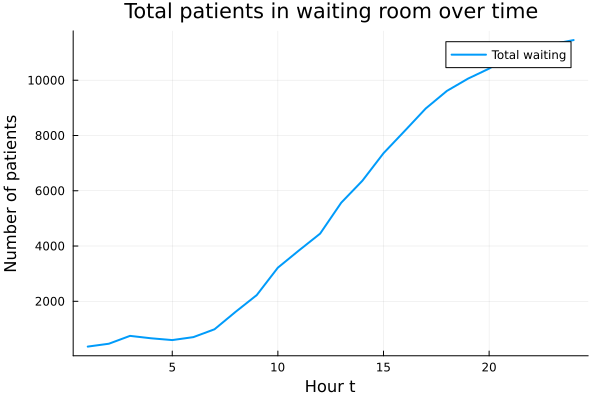

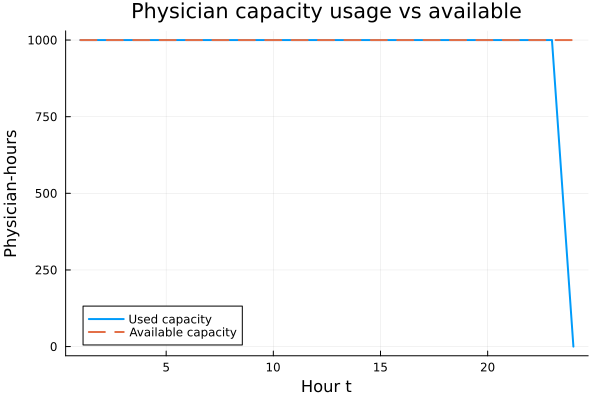

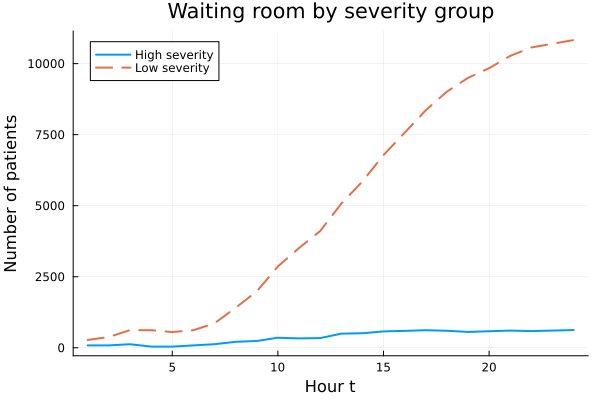

In [44]:
using Plots

# Extract solution
W_val = value.(W)
X_val = value.(X)

# 1) Total patients in the waiting room over time
wait_total = [sum(W_val[i, t] for i in I) for t in 1:T]

p1 = plot(
    1:T,
    wait_total,
    xlabel = "Hour t",
    ylabel = "Number of patients",
    title = "Total patients in waiting room over time",
    label = "Total waiting",
    legend = :topright,
    lw = 2,
)

# 2) Physician capacity usage vs available capacity over time
cap_used = [sum(tau[i] * X_val[i, t] for i in I) for t in 1:T]
cap_avail = [Cap[t] for t in 1:T]

p2 = plot(
    1:T,
    cap_used,
    xlabel = "Hour t",
    ylabel = "Physician-hours",
    title = "Physician capacity usage vs available",
    label = "Used capacity",
    lw = 2,
)
plot!(p2, 1:T, cap_avail, label = "Available capacity", ls = :dash, lw = 2)

# 3) Waiting room split by severity (high vs low severity)
# Define what you consider "high severity"
high_severity = [i for i in I if s[i] >= 3]    # example: severity >= 3
low_severity  = [i for i in I if s[i] < 3]

wait_high = [sum(W_val[i, t] for i in high_severity) for t in 1:T]
wait_low  = [sum(W_val[i, t] for i in low_severity)  for t in 1:T]

p3 = plot(
    1:T,
    wait_high,
    xlabel = "Hour t",
    ylabel = "Number of patients",
    title = "Waiting room by severity group",
    label = "High severity",
    lw = 2,
)
plot!(p3, 1:T, wait_low, label = "Low severity", lw = 2, ls = :dash)

# Show all
display(p1)
display(p2)
display(p3)

# Optional: save
# savefig(p1, "modelA_waiting_total.png")
# savefig(p2, "modelA_capacity.png")
# savefig(p3, "modelA_waiting_by_severity.png")

#### Now by explicitly adding age in queue in the model (like we did initially).

In [45]:
I = 1:20
T = 24
A = 0:T    # max age in queue (in hours)

# Parameters
tau = Dict(i => waiting_df.typical_treatment_time[i] for i in I)
s   = Dict(i => waiting_df.severity_score[i] for i in I)   # your severity

Cap = Dict(t => 1000.0 for t in 1:T)

N = Dict((Int(row.disease_index), Int(row.t)) => Float64(row.arrivals)
         for row in eachrow(arrivals_df))

# Age-dependent penalty: c[i,a] = s[i] * a  (or s[i] * (1 + alpha*a))
alpha = 0.2
c = Dict((i,a) => s[i] * (1.0 + alpha * a) for i in I, a in A)

model = Model(Gurobi.Optimizer)

@variable(model, w[i in I, t in 1:T, a in A] >= 0)
@variable(model, x[i in I, t in 1:T, a in A] >= 0)

# New arrivals at age 0
@constraint(model, [i in I, t in 1:T],
    w[i,t,0] == N[(i,t)]
)

# Optional: initial backlog older than 0 at t = 1 (set to 0 if none)
@constraint(model, [i in I, a in 1:T],
    w[i,1,a] == 0
)

# Queue dynamics
@constraint(model, [i in I, t in 1:T-1, a in 0:T-1],
    w[i, t+1, a+1] == w[i,t,a] - x[i,t,a]
)

# Cannot treat more than waiting
@constraint(model, [i in I, t in 1:T, a in A],
    x[i,t,a] <= w[i,t,a]
)

# Capacity per period
@constraint(model, [t in 1:T],
    sum(tau[i] * x[i,t,a] for i in I, a in A) <= Cap[t]
)

# Objective: severity × age-dependent penalty
@objective(model, Min,
    sum(c[(i,a)] * w[i,t,a] for i in I, t in 1:T, a in A)
)

optimize!(model)

Set parameter Username
Set parameter LicenseID to value 2697134
Academic license - for non-commercial use only - expires 2026-08-20
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Optimize a model with 24024 rows, 24000 columns and 70080 nonzeros
Model fingerprint: 0x499ad7be
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+00, 1e+03]
Presolve removed 22309 rows and 18611 columns
Presolve time: 0.01s
Presolved: 1715 rows, 5389 columns, 13543 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 8.055e+03
 Factor NZ  : 1.678e+04 (roughly 2 MB of memory)
 Factor Ops : 2.828e+05 (less than 1 second per iteration)
 Threads    : 1

                

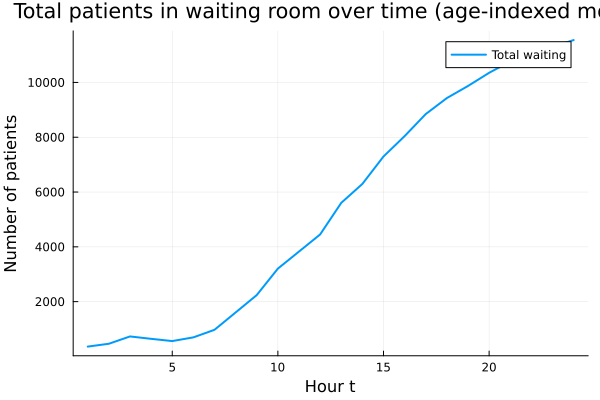

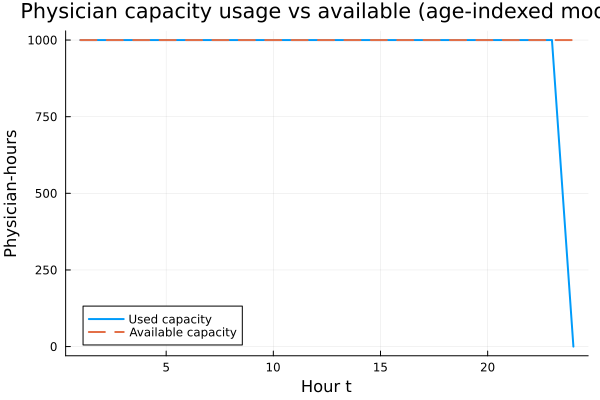

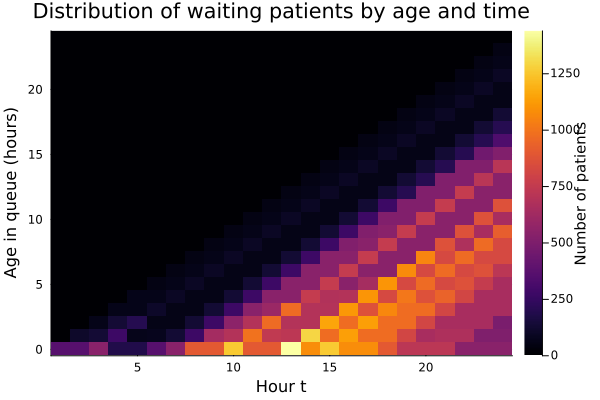

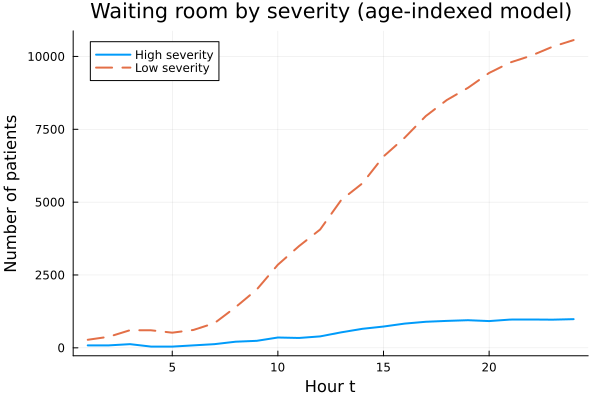

In [46]:
using Plots

w_val = value.(w)
x_val = value.(x)

# Helper: age index set A
A_vec = collect(A)  # 0:T as a vector

# 1) Total waiting over time (aggregated over age & disease)
wait_total = [
    sum(w_val[i, t, a] for i in I, a in A)
    for t in 1:T
]

p1 = plot(
    1:T,
    wait_total,
    xlabel = "Hour t",
    ylabel = "Number of patients",
    title = "Total patients in waiting room over time (age-indexed model)",
    label = "Total waiting",
    lw = 2,
    legend = :topright,
)

# 2) Physician capacity usage vs available
cap_used = [
    sum(tau[i] * sum(x_val[i, t, a] for a in A) for i in I)
    for t in 1:T
]
cap_avail = [Cap[t] for t in 1:T]

p2 = plot(
    1:T,
    cap_used,
    xlabel = "Hour t",
    ylabel = "Physician-hours",
    title = "Physician capacity usage vs available (age-indexed model)",
    label = "Used capacity",
    lw = 2,
)
plot!(p2, 1:T, cap_avail, label = "Available capacity", ls = :dash, lw = 2)

# 3) Heatmap of age distribution in the waiting room (total over diseases)
#    For each hour t and age a, compute number of patients waiting.
wait_by_age = [
    sum(w_val[i, t, a] for i in I)
    for a in A, t in 1:T
]
# wait_by_age is a matrix with rows = age a, columns = time t

p3 = heatmap(
    1:T,
    A_vec,
    wait_by_age,
    xlabel = "Hour t",
    ylabel = "Age in queue (hours)",
    title = "Distribution of waiting patients by age and time",
    colorbar_title = "Number of patients",
)

# Optional extra: high vs low severity waiting over time (any age)
high_severity = [i for i in I if s[i] >= 3]
low_severity  = [i for i in I if s[i] < 3]

wait_high = [
    sum(w_val[i, t, a] for i in high_severity, a in A)
    for t in 1:T
]
wait_low = [
    sum(w_val[i, t, a] for i in low_severity, a in A)
    for t in 1:T
]

p4 = plot(
    1:T,
    wait_high,
    xlabel = "Hour t",
    ylabel = "Number of patients",
    title = "Waiting room by severity (age-indexed model)",
    label = "High severity",
    lw = 2,
)
plot!(p4, 1:T, wait_low, label = "Low severity", lw = 2, ls = :dash)

# Show plots
display(p1)
display(p2)
display(p3)
display(p4)

# Optional saves:
# savefig(p1, "modelB_waiting_total.png")
# savefig(p2, "modelB_capacity.png")
# savefig(p3, "modelB_wait_age_heatmap.png")
# savefig(p4, "modelB_wait_by_severity.png")

#### With these two models we have improved life interpretability and logic.
#### Now let's add another complexity to the model, we take into consideration doctors qualifications.
#### Each doctor has severity-knowledge and can take care of patients with the same severity or below but not over.
#### Let's see the evolution of the patients in the waiting room now.

In [47]:
# ----------------------------------------------------------------------
# Sets
# ----------------------------------------------------------------------
I = 1:20            # diseases/symptoms
T = 24              # time periods (hours)
A = 0:T             # age in queue (0..T hours)
L = 1:4             # physician levels (1..4)

# ----------------------------------------------------------------------
# Parameters from your data
# ----------------------------------------------------------------------

# Service time per disease/symptom τ_i
tau = Dict(i => waiting_df.typical_treatment_time[i] for i in I)

# Severity score s_i (integer 0..4, as we defined earlier)
s = Dict(i => waiting_df.severity_score[i] for i in I)

# Arrivals: N[(i,t)] = # of patients of class i arriving at hour t
N = Dict((Int(row.disease_index), Int(row.t)) => Float64(row.arrivals)
         for row in eachrow(arrivals_df))

# Physician counts by level (per hour)
physicians_per_level = Dict(
    1 => 500.0,
    2 => 300.0,
    3 => 150.0,
    4 => 50.0,
)

# ----------------------------------------------------------------------
# Model
# ----------------------------------------------------------------------
model = Model(Gurobi.Optimizer)

# Waiting patients with age structure
@variable(model, w[i in I, t in 1:T, a in A] >= 0)

# Patients treated by physician level ℓ
# Only define y[i,t,a,l] when severity is compatible: s[i] <= l
@variable(model, y[i in I, t in 1:T, a in A, l in L; s[i] <= l] >= 0)

# ----------------------------------------------------------------------
# New arrivals at age 0
# ----------------------------------------------------------------------
@constraint(model, [i in I, t in 1:T],
    w[i,t,0] == N[(i,t)]
)

# Optional: no initial backlog older than 0 at t = 1
@constraint(model, [i in I, a in 1:T],
    w[i,1,a] == 0
)

# ----------------------------------------------------------------------
# Queue dynamics:
# w[i, t+1, a+1] = w[i,t,a] - sum_l y[i,t,a,l]
# ----------------------------------------------------------------------
@constraint(model, [i in I, t in 1:T-1, a in 0:T-1],
    w[i, t+1, a+1] ==
        w[i,t,a] - sum(y[i,t,a,l] for l in L if s[i] <= l)
)

# ----------------------------------------------------------------------
# You can't treat more patients than are waiting at (i,t,a)
# sum_l y[i,t,a,l] <= w[i,t,a]
# ----------------------------------------------------------------------
@constraint(model, [i in I, t in 1:T, a in A],
    sum(y[i,t,a,l] for l in L if s[i] <= l) <= w[i,t,a]
)

# ----------------------------------------------------------------------
# Capacity constraints per physician level and time:
# sum_{i,a} τ_i * y[i,t,a,l] <= physicians_per_level[l]
# (only for i with s[i] <= l)
# ----------------------------------------------------------------------
@constraint(model, [l in L, t in 1:T],
    sum(tau[i] * sum(y[i,t,a,l] for a in A)
        for i in I if s[i] <= l) <= physicians_per_level[l]
)

# ----------------------------------------------------------------------
# Objective: linear waiting cost with severity
# Each waiting patient of class i costs s[i] per hour of waiting
# ----------------------------------------------------------------------
@objective(model, Min,
    sum(s[i] * w[i,t,a] for i in I, t in 1:T, a in A)
)

optimize!(model)

Set parameter Username
Set parameter LicenseID to value 2697134
Academic license - for non-commercial use only - expires 2026-08-20
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Optimize a model with 24096 rows, 49800 columns and 145416 nonzeros
Model fingerprint: 0x9cea329e
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+00, 4e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+00, 5e+02]
Presolve removed 21116 rows and 35587 columns
Presolve time: 0.03s
Presolved: 2980 rows, 14213 columns, 37832 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.01s

Barrier statistics:
 AA' NZ     : 2.020e+04
 Factor NZ  : 4.723e+04 (roughly 6 MB of memory)
 Factor Ops : 1.921e+06 (less than 1 second per iteration)
 Threads    : 1

              

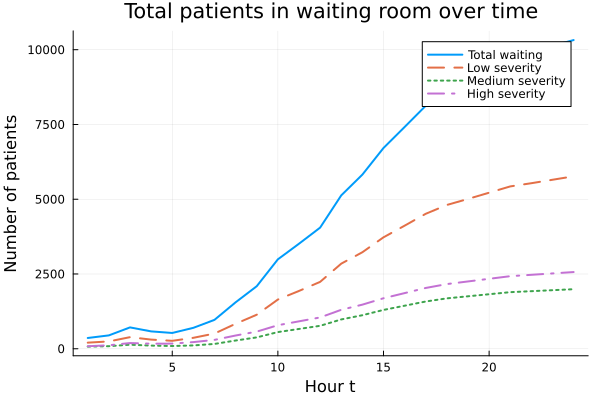

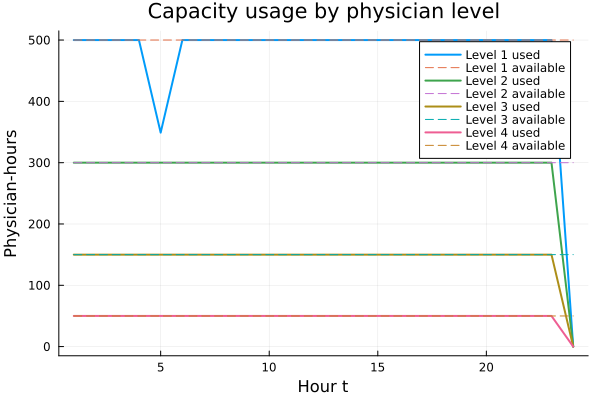

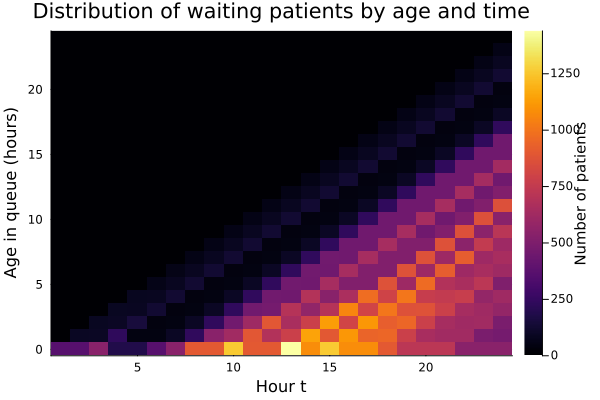

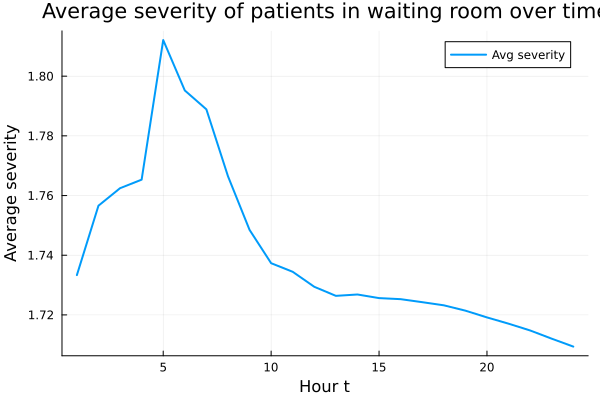

In [48]:
using Plots

# ----------------------------------------------------------------------
# Get solution values
# ----------------------------------------------------------------------
w_val = value.(w)
y_val = value.(y)

# basic helpers
A_vec = collect(A)   # ages 0..T as a vector

# severity bands (tune thresholds if you want)
low_sev     = [i for i in I if s[i] <= 1]
medium_sev  = [i for i in I if s[i] == 2]
high_sev    = [i for i in I if s[i] >= 3]

# ----------------------------------------------------------------------
# 1) Total waiting + by severity over time
# ----------------------------------------------------------------------

wait_total = [
    sum(w_val[i,t,a] for i in I, a in A)
    for t in 1:T
]

wait_low = [
    sum(w_val[i,t,a] for i in low_sev, a in A)
    for t in 1:T
]

wait_med = [
    sum(w_val[i,t,a] for i in medium_sev, a in A)
    for t in 1:T
]

wait_high = [
    sum(w_val[i,t,a] for i in high_sev, a in A)
    for t in 1:T
]

p1 = plot(
    1:T, wait_total,
    xlabel = "Hour t",
    ylabel = "Number of patients",
    title  = "Total patients in waiting room over time",
    label  = "Total waiting",
    lw     = 2,
    legend = :topright,
)

# same figure: overlay severity bands
plot!(p1, 1:T, wait_low,  label = "Low severity",  lw = 2, ls = :dash)
plot!(p1, 1:T, wait_med,  label = "Medium severity", lw = 2, ls = :dot)
plot!(p1, 1:T, wait_high, label = "High severity", lw = 2, ls = :dashdot)

display(p1)

# ----------------------------------------------------------------------
# 2) Capacity usage per physician level vs available
# ----------------------------------------------------------------------

# capacity used by each level l at time t
cap_used = Dict{Int, Vector{Float64}}()
for l in L
    cap_used[l] = [
        sum(tau[i] * sum(y_val[i,t,a,l] for a in A)
            for i in I if s[i] <= l)
        for t in 1:T
    ]
end

p2 = plot(
    xlabel = "Hour t",
    ylabel = "Physician-hours",
    title  = "Capacity usage by physician level",
    legend = :topright,
)

for l in L
    plot!(p2, 1:T, cap_used[l],
        label = "Level $l used",
        lw    = 2,
    )
    # available capacity per level is just #physicians_per_level[l]
    plot!(p2, 1:T,
        [physicians_per_level[l] for _ in 1:T],
        label = "Level $l available",
        lw    = 1,
        ls    = :dash,
    )
end

display(p2)

# ----------------------------------------------------------------------
# 3) Heatmap of queue age distribution over time
# ----------------------------------------------------------------------

# wait_by_age[a,t] = total patients of age a at time t (summed over diseases)
wait_by_age = [
    sum(w_val[i,t,a] for i in I)
    for a in A, t in 1:T
]

p3 = heatmap(
    1:T,            # x = time
    A_vec,          # y = age in queue
    wait_by_age,
    xlabel = "Hour t",
    ylabel = "Age in queue (hours)",
    title  = "Distribution of waiting patients by age and time",
    colorbar_title = "Number of patients",
)

display(p3)

# ----------------------------------------------------------------------
# 4) (Bonus) Average severity of patients in the waiting room over time
# ----------------------------------------------------------------------

avg_severity = Float64[]
for t in 1:T
    total_patients_t = sum(w_val[i,t,a] for i in I, a in A)
    if total_patients_t > 0
        weighted_sev_t = sum(s[i] * sum(w_val[i,t,a] for a in A) for i in I)
        push!(avg_severity, weighted_sev_t / total_patients_t)
    else
        push!(avg_severity, 0.0)
    end
end

p4 = plot(
    1:T, avg_severity,
    xlabel = "Hour t",
    ylabel = "Average severity",
    title  = "Average severity of patients in waiting room over time",
    label  = "Avg severity",
    lw     = 2,
)

display(p4)

# ----------------------------------------------------------------------
# Optional: save plots
# ----------------------------------------------------------------------
# savefig(p1, "waiting_by_severity.png")
# savefig(p2, "capacity_by_level.png")
# savefig(p3, "waiting_age_heatmap.png")
# savefig(p4, "average_severity_over_time.png")

for each disease i, what % of its patients were treated by each physician level l

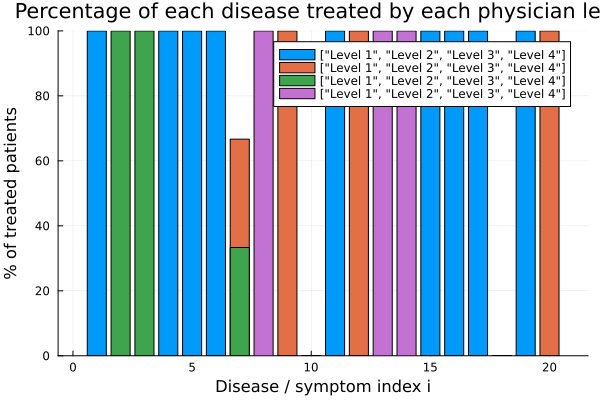

┌ Warning: Keyword argument bar_position not supported with Plots.GRBackend().  Choose from: annotationcolor, annotationfontfamily, annotationfontsize, annotationhalign, annotationrotation, annotations, annotationvalign, arrow, aspect_ratio, axis, background_color, background_color_inside, background_color_outside, background_color_subplot, bar_width, bins, bottom_margin, camera, clims, color_palette, colorbar, colorbar_entry, colorbar_scale, colorbar_title, colorbar_titlefont, colorbar_titlefontcolor, colorbar_titlefontrotation, colorbar_titlefontsize, connections, contour_labels, discrete_values, fill, fill_z, fillalpha, fillcolor, fillrange, fillstyle, flip, fontfamily, fontfamily_subplot, foreground_color, foreground_color_axis, foreground_color_border, foreground_color_grid, foreground_color_subplot, foreground_color_text, formatter, framestyle, grid, gridalpha, gridlinewidth, gridstyle, group, guide, guidefont, guidefontcolor, guidefontfamily, guidefonthalign, guidefontrotation, 

In [49]:
y_val = value.(y)

# ----------------------------------------------------------------------
# 1) Compute, for each disease i, how many patients were treated,
#    and how many by each physician level l
# ----------------------------------------------------------------------

# Total treated patients per disease i (all levels)
total_treated = Dict{Int, Float64}()

for i in I
    total_treated[i] = sum(
        y_val[i,t,a,l]
        for t in 1:T, a in A, l in L
        if s[i] <= l   # y is only defined when s[i] <= l
    )
end

# Share[(i,l)] = fraction of class i patients treated by level l
share = Dict{Tuple{Int,Int}, Float64}()

for i in I, l in L
    if s[i] <= l && total_treated[i] > 0
        treated_by_l = sum(
            y_val[i,t,a,l]
            for t in 1:T, a in A
        )
        share[(i,l)] = treated_by_l / total_treated[i]
    else
        share[(i,l)] = 0.0
    end
end

# ----------------------------------------------------------------------
# 2) Build percentage matrix for plotting
#    perc[l, i] = % of disease i handled by level l
# ----------------------------------------------------------------------
perc = [share[(i,l)] * 100 for l in L, i in I]  # |L| x |I| matrix

# ----------------------------------------------------------------------
# 3) Stacked bar plot: for each disease i, % by physician level
# ----------------------------------------------------------------------
disease_indices = collect(I)
level_labels    = ["Level $l" for l in L]

p_levels_by_disease = bar(
    disease_indices,
    permutedims(perc),             # now rows = diseases, columns = levels
    bar_position = :stack,         # stack to show percentages summing to 100
    xlabel = "Disease / symptom index i",
    ylabel = "% of treated patients",
    title  = "Percentage of each disease treated by each physician level",
    label  = level_labels,
    legend = :topright,
)

display(p_levels_by_disease)

# Optional: save
# savefig(p_levels_by_disease, "percent_by_level_per_disease.png")

### Second model: λ is not 0 and α = 0

#### Objective: minimize ∑_{t,i,a} g_i * w_{i,t,a} + λ* ∑_{i,t} z_{i,t}
#### Dynamics:
####   w[i,t+1,a+1] = w[i,t,a] - x[i,t,a]
####   w[i,t,1]     = N[i,t]  (new arrivals at a=0)

#### Capacity per time t is fixed input Cap[t]

In [9]:
using CSV, DataFrames
using JuMP, Gurobi



# Physician capacity parameters
C_phys   = 4.0        # capacity of one physician per period (for example 4 patient hours)
Z_max    = 15         # maximum number of physicians available

# Hospital cost weight λ
lambda_hosp = 0.5     # you can play with this value

# =========================
# 3. Model with physician decision z[t]
# =========================

model_2 = Model(Gurobi.Optimizer)

@variable(model_2, w[i in I, t in 1:T, a in A] >= 0, Int)
@variable(model_2, x[i in I, t in 1:T, a in A] >= 0, Int)

# Number of physicians on duty at time t
@variable(model_2, z[t in 1:T] >= 0, Int)

# x ≤ w
@constraint(model_2, [i in I, t in 1:T, a in A], x[i,t,a] <= w[i,t,a])

# New arrivals at age 0
@constraint(model_2, [i in I, t in 1:T], w[i,t,0] == N[(i,t)])

# Queue dynamics
@constraint(model_2, [i in I, t in 1:T-1, a in 0:T-1],
    w[i, t+1, a+1] == w[i,t,a] - x[i,t,a]
)

# Treatment capacity with physician decision
@constraint(model_2, capacity[t in 1:T],
    sum(tau[i] * x[i,t,a] for i in I, a in A) <= C_phys * z[t]
)

# Maximum number of physicians
@constraint(model_2, [t in 1:T], z[t] <= Z_max)

# =========================
# 4. Objective
# =========================
# Patient waiting cost  plus  hospital cost of physicians

@objective(model_2, Min,
    sum(g[i] * w[i,t,a] for i in I, t in 1:T, a in A) +
    lambda_hosp * sum(z[t] for t in 1:T)
)

optimize!(model_2)

# =========================
# 5. Inspect some results
# =========================

println("Objective value = ", objective_value(model))
println("Physicians per period:")
for t in 1:T
    println("t = ", t, ", z[t] = ", value(z[t]))
end



Set parameter Username
Set parameter LicenseID to value 2697134
Academic license - for non-commercial use only - expires 2026-08-20
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Optimize a model with 23568 rows, 24024 columns and 69648 nonzeros
Model fingerprint: 0x1f0027f5
Variable types: 0 continuous, 24024 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [5e-01, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+00, 1e+02]
Presolve removed 23493 rows and 23393 columns
Presolve time: 0.03s
Presolved: 75 rows, 631 columns, 1234 nonzeros
Variable types: 0 continuous, 631 integer (0 binary)
Found heuristic solution: objective 199246.50000
Found heuristic solution: objective 199245.50000

Root relaxation: objective 1.914015e+05, 154 iterations, 0.00 seconds (0.00 work units)

    Nodes   

### 3rd MODEL alpha not 0 and lambda = 0

#### Objective: minimize ∑_{t,i,a} g_i * w_{i,t,a} * (1 + alpha_i * a)